#This is the eval Metrics for Config + Helper

## Task
**Calculate the success rates for the three Config generation on modelio**


In [1]:
import json

file_paths = [
    '/content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl',
    '/content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl',
    '/content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl'
]

parsed_data = {}

for file_path in file_paths:
    file_data = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                file_data.append(json.loads(line))
        parsed_data[file_path] = file_data
        print(f"Successfully loaded {len(file_data)} objects from {file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {file_path}: {e}")


Error: File not found at /content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl
Error: File not found at /content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl
Error: File not found at /content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
success_rates = {}

for file_path, data in parsed_data.items():
    total_entries = len(data)
    successful_entries = 0
    for entry in data:
        if entry.get('execution_error') is None:
            successful_entries += 1

    if total_entries > 0:
        success_rate = (successful_entries / total_entries) * 100
    else:
        success_rate = 0

    success_rates[file_path] = success_rate
    print(f"File: {file_path}\nTotal entries: {total_entries}\nSuccessful entries: {successful_entries}\nSuccess rate: {success_rate:.2f}%\n")

print("\n--- Summary of Success Rates ---")
for file_path, rate in success_rates.items():
    print(f"{file_path}: {rate:.2f}%")

File: /content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl
Total entries: 55
Successful entries: 55
Success rate: 100.00%

File: /content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl
Total entries: 55
Successful entries: 55
Success rate: 100.00%

File: /content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl
Total entries: 55
Successful entries: 50
Success rate: 90.91%


--- Summary of Success Rates ---
/content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl: 100.00%
/content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl: 100.00%
/content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl: 90.91%



**Calculate the Generation time of LLMs for the three Config generation**


In [ ]:
import json
import pandas as pd

# JSONL files for generation time
files_gen_time = {
    "GLM5": "/content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "/content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "/content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl"
}

def compute_generation_time_stats(file_path, model_name):
    times = []

    with open(file_path, "r") as f:
        for line in f:
            sample = json.loads(line)

            if sample.get("execution_success") is False:
                continue

            # Adjust key depending on model
            if model_name == "GLM5":
                gen_time = sample.get("glm5_config_generation_time")
            elif model_name == "GPT_5_2":
                gen_time = sample.get("gpt52_config_generation_time")
            elif model_name == "Claude_Opus_4_5":
                gen_time = sample.get("claudeopus_config_generation_time")
            else:
                gen_time = None

            if gen_time is not None:
                times.append(gen_time)

    if not times:
        return {"Average": None, "Min": None, "Max": None}

    return {
        "Average": round(sum(times)/len(times), 2),
        "Min": round(min(times), 2),
        "Max": round(max(times), 2)
    }

# Compute stats for each model
summary_rows = []
for model, path in files_gen_time.items():
    stats = compute_generation_time_stats(path, model)
    summary_rows.append({
        "Model": model,
        "Average_Generation_Time": stats["Average"],
        "Min_Generation_Time": stats["Min"],
        "Max_Generation_Time": stats["Max"]
    })

# Display results
gen_time_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
print("=== Generation Time Summary per Model (seconds) ===")
print(gen_time_df)

=== Generation Time Summary per Model (seconds) ===
             Model  Average_Generation_Time  Min_Generation_Time  \
0             GLM5                   201.13                14.88   
1          GPT_5_2                    49.45                10.33   
2  Claude_Opus_4_5                    22.35                 9.89   

   Max_Generation_Time  
0               834.52  
1               132.17  
2                44.91  


**Calculate token counts stats for the 3 LLMs**


In [ ]:
import json
import pandas as pd

# JSONL files for token stats
files_tokens = {
    "GLM5": "/content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "/content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "/content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl"
}

def compute_token_stats(file_path, model_name):
    input_tokens_list = []
    output_tokens_list = []
    total_tokens_list = []

    with open(file_path, "r") as f:
        for line in f:
            entry = json.loads(line)

            if entry.get("execution_success") is False:
                continue

            if model_name == "GLM5":
                input_tokens = entry.get('glm5_config_input_tokens')
                output_tokens = entry.get('glm5_config_output_tokens')
                total_tokens = entry.get('glm5_config_total_tokens')
            elif model_name == "GPT_5_2":
                input_tokens = entry.get('gpt52_config_input_tokens')
                output_tokens = entry.get('gpt52_config_output_tokens')
                total_tokens = entry.get('gpt52_config_total_tokens')
            elif model_name == "Claude_Opus_4_5":
                input_tokens = entry.get('claudeopus_config_input_tokens')
                output_tokens = entry.get('claudeopus_config_output_tokens')
                total_tokens = entry.get('claudeopus_config_total_tokens')
            else:
                continue

            if input_tokens is not None:
                input_tokens_list.append(input_tokens)
            if output_tokens is not None:
                output_tokens_list.append(output_tokens)
            if total_tokens is not None:
                total_tokens_list.append(total_tokens)

    def summarize(lst):
        if not lst:
            return {"Average": None, "Min": None, "Max": None}
        return {"Average": round(sum(lst)/len(lst), 2), "Min": min(lst), "Max": max(lst)}

    return {
        "Input_Tokens": summarize(input_tokens_list),
        "Output_Tokens": summarize(output_tokens_list),
        "Total_Tokens": summarize(total_tokens_list)
    }

# Compute stats per model
summary_rows = []
for model, path in files_tokens.items():
    stats = compute_token_stats(path, model)
    summary_rows.append({
        "Model": model,
        "Input_Tokens_Avg": stats["Input_Tokens"]["Average"],
        "Input_Tokens_Min": stats["Input_Tokens"]["Min"],
        "Input_Tokens_Max": stats["Input_Tokens"]["Max"],
        "Output_Tokens_Avg": stats["Output_Tokens"]["Average"],
        "Output_Tokens_Min": stats["Output_Tokens"]["Min"],
        "Output_Tokens_Max": stats["Output_Tokens"]["Max"],
        "Total_Tokens_Avg": stats["Total_Tokens"]["Average"],
        "Total_Tokens_Min": stats["Total_Tokens"]["Min"],
        "Total_Tokens_Max": stats["Total_Tokens"]["Max"]
    })

# Display results
tokens_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
print("=== Token Statistics per Model ===")
print(tokens_df)

=== Token Statistics per Model ===
             Model  Input_Tokens_Avg  Input_Tokens_Min  Input_Tokens_Max  \
0             GLM5           3117.94              3000              3947   
1          GPT_5_2           3135.67              3012              3957   
2  Claude_Opus_4_5           3637.56              3509              4516   

   Output_Tokens_Avg  Output_Tokens_Min  Output_Tokens_Max  Total_Tokens_Avg  \
0            8567.32               1528              18738          11685.26   
1            3467.04                756               9617           6602.71   
2            1795.78                738               3970           5433.35   

   Total_Tokens_Min  Total_Tokens_Max  
0              4585             21884  
1              3770             12979  
2              4277              7743  


In [ ]:
print("\n--- Token Generation Statistics Summary ---")

# Claude Opus Summary
print("\n### Claude Opus")
print(f"  Input Tokens:   Average={avg_claude_input_tokens:.2f}, Max={max_claude_input_tokens:.2f}, Min={min_claude_input_tokens:.2f}")
print(f"  Output Tokens:  Average={avg_claude_output_tokens:.2f}, Max={max_claude_output_tokens:.2f}, Min={min_claude_output_tokens:.2f}")
print(f"  Total Tokens:   Average={avg_claude_total_tokens:.2f}, Max={max_claude_total_tokens:.2f}, Min={min_claude_total_tokens:.2f}")

# GPT-5.2 Summary
print("\n### GPT-5.2")
print(f"  Input Tokens:   Average={avg_gpt_input_tokens:.2f}, Max={max_gpt_input_tokens:.2f}, Min={min_gpt_input_tokens:.2f}")
print(f"  Output Tokens:  Average={avg_gpt_output_tokens:.2f}, Max={max_gpt_output_tokens:.2f}, Min={min_gpt_output_tokens:.2f}")
print(f"  Total Tokens:   Average={avg_gpt_total_tokens:.2f}, Max={max_gpt_total_tokens:.2f}, Min={min_gpt_total_tokens:.2f}")

# GLM5 Summary
print("\n### GLM5")
print(f"  Input Tokens:   Average={avg_glm_input_tokens:.2f}, Max={max_glm_input_tokens:.2f}, Min={min_glm_input_tokens:.2f}")
print(f"  Output Tokens:  Average={avg_glm_output_tokens:.2f}, Max={max_glm_output_tokens:.2f}, Min={min_glm_output_tokens:.2f}")
print(f"  Total Tokens:   Average={avg_glm_total_tokens:.2f}, Max={max_glm_total_tokens:.2f}, Min={min_glm_total_tokens:.2f}")


--- Token Generation Statistics Summary ---

### Claude Opus
  Input Tokens:   Average=3637.56, Max=4516.00, Min=3509.00
  Output Tokens:  Average=1795.78, Max=3970.00, Min=738.00
  Total Tokens:   Average=5433.35, Max=7743.00, Min=4277.00

### GPT-5.2
  Input Tokens:   Average=3135.67, Max=3957.00, Min=3012.00
  Output Tokens:  Average=3467.04, Max=9617.00, Min=756.00
  Total Tokens:   Average=6602.71, Max=12979.00, Min=3770.00

### GLM5
  Input Tokens:   Average=3124.49, Max=3947.00, Min=3000.00
  Output Tokens:  Average=8546.75, Max=18738.00, Min=1528.00
  Total Tokens:   Average=11671.24, Max=21884.00, Min=4585.00


##This part will be about the computational metrics

**Calculate the Mean Absolute Error (MAE)**


In [ ]:
import json
import pandas as pd

# JSONL files
files = {
    "GLM5": "/content/exp_config_helper/generated_configs_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "/content/exp_config_helper/generated_configs_helper_GPT_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "/content/exp_config_helper/generated_configs_modelio_claude_opus_4_5.jsonl"
}

metrics = ["lanes", "elements", "gateways", "flows", "data_objects", "data_assoc"]

def compute_detailed_stats_with_json(file_path):
    rows = []

    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            sample = json.loads(line)

            if sample.get("execution_success") is False:
                continue

            gt = sample.get("complexity_metrics", {})
            gen = sample.get("generated_metrics", {})

            # Map generated metrics
            generated = {
                "lanes": sample.get("lanes", 0),
                "elements": sample.get("elements", 0),
                "gateways": sample.get("gateways", 0),
                "flows": sample.get("flows", 0),
                "data_objects": sample.get("data", 0),   # data → data_objects
                "data_assoc": sample.get("data_assoc", 0)
            }

            groundtruth = {
                "lanes": gt.get("lanes", 0),
                "elements": gt.get("elements", 0),
                "gateways": gt.get("gateways", 0),
                "flows": gt.get("flows", 0),
                "data_objects": gt.get("data_objects", 0),
                "data_assoc": gt.get("data_assoc", 0)
            }

            # Compute absolute errors
            abs_errors = {m: abs(generated[m] - groundtruth[m]) for m in metrics}

            # Create row with GT, GEN, ABS_ERR, and raw JSONs
            row = {
                "Sample_Index": i,
                "GT_JSON": json.dumps(gt),
                "GEN_JSON": json.dumps(gen),
                **{f"GT_{m}": groundtruth[m] for m in metrics},
                **{f"GEN_{m}": generated[m] for m in metrics},
                **{f"ABS_ERR_{m}": abs_errors[m] for m in metrics}
            }

            rows.append(row)

    df = pd.DataFrame(rows)

    # Compute MAE per metric and overall
    mae_per_metric = {m: df[f"ABS_ERR_{m}"].mean() for m in metrics}
    overall_mae = df[[f"ABS_ERR_{m}" for m in metrics]].values.mean()
    valid_samples = len(df)

    return df, mae_per_metric, overall_mae, valid_samples


# Stocker les résultats par modèle
all_results = {}
summary_rows = []

for model, path in files.items():
    detailed_df, mae_metrics, overall_mae, n = compute_detailed_stats_with_json(path)
    all_results[model] = detailed_df

    summary_row = {
        "Model": model,
        "Valid_Samples": n,
        "Overall_MAE": round(overall_mae, 3)
    }
    summary_row.update({m: round(mae_metrics[m], 3) for m in metrics})
    summary_rows.append(summary_row)

# Table de synthèse
summary_df = pd.DataFrame(summary_rows)

# Affichage
pd.set_option('display.max_columns', None)
print("=== Summary MAE per model ===")
print(summary_df.round(3))

# Exemple: accéder au détail d'un modèle
#all_results["GLM5"]

=== Summary MAE per model ===
             Model  Valid_Samples  Overall_MAE  lanes  elements  gateways  \
0             GLM5             50        4.360  1.740     7.180     5.260   
1          GPT_5_2             55        4.079  2.182     5.345     4.818   
2  Claude_Opus_4_5             55        4.218  2.182     4.709     4.636   

    flows  data_objects  data_assoc  
0  10.140         0.680       1.160  
1   7.709         1.491       2.927  
2   6.655         2.545       4.582  


#This is the eval Metrics for Native ( No helper )

## Task
**Calculate the success rates for the three Config generation on modelio**

In [ ]:
import json

file_paths = [
    '/content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl',
    '/content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl',
    '/content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl'
]


parsed_data = {}

for file_path in file_paths:
    file_data = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                file_data.append(json.loads(line))
        parsed_data[file_path] = file_data
        print(f"Successfully loaded {len(file_data)} objects from {file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {file_path}: {e}")


Successfully loaded 55 objects from /content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl
Successfully loaded 55 objects from /content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl
Successfully loaded 55 objects from /content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl


In [ ]:
success_rates = {}

for file_path, data in parsed_data.items():
    total_entries = len(data)
    successful_entries = 0
    for entry in data:
        if entry.get('execution_error') is None:
            successful_entries += 1

    if total_entries > 0:
        success_rate = (successful_entries / total_entries) * 100
    else:
        success_rate = 0

    success_rates[file_path] = success_rate
    print(f"File: {file_path}\nTotal entries: {total_entries}\nSuccessful entries: {successful_entries}\nSuccess rate: {success_rate:.2f}%\n")

print("\n--- Summary of Success Rates ---")
for file_path, rate in success_rates.items():
    print(f"{file_path}: {rate:.2f}%")

File: /content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl
Total entries: 55
Successful entries: 55
Success rate: 100.00%

File: /content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl
Total entries: 55
Successful entries: 55
Success rate: 100.00%

File: /content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl
Total entries: 55
Successful entries: 48
Success rate: 87.27%


--- Summary of Success Rates ---
/content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl: 100.00%
/content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl: 100.00%
/content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl: 87.27%


**Calculate token counts stats for the 3 LLMs**


In [ ]:
import json
import pandas as pd

# JSONL files for token stats
files_tokens = {
    "GLM5": "/content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "/content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "/content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl"
}

def compute_token_stats(file_path, model_name):
    input_tokens_list = []
    output_tokens_list = []
    total_tokens_list = []

    with open(file_path, "r") as f:
        for line in f:
            entry = json.loads(line)

            if entry.get("execution_success") is False:
                continue

            if model_name == "GLM5":
                input_tokens = entry.get('glm5_config_input_tokens')
                output_tokens = entry.get('glm5_config_output_tokens')
                total_tokens = entry.get('glm5_config_total_tokens')
            elif model_name == "GPT_5_2":
                input_tokens = entry.get('gpt52_config_input_tokens')
                output_tokens = entry.get('gpt52_config_output_tokens')
                total_tokens = entry.get('gpt52_config_total_tokens')
            elif model_name == "Claude_Opus_4_5":
                input_tokens = entry.get('claudeopus45_config_input_tokens')
                output_tokens = entry.get('claudeopus45_config_output_tokens')
                total_tokens = entry.get('claudeopus45_config_total_tokens')
            else:
                continue

            if input_tokens is not None:
                input_tokens_list.append(input_tokens)
            if output_tokens is not None:
                output_tokens_list.append(output_tokens)
            if total_tokens is not None:
                total_tokens_list.append(total_tokens)

    def summarize(lst):
        if not lst:
            return {"Average": None, "Min": None, "Max": None}
        return {"Average": round(sum(lst)/len(lst), 2), "Min": min(lst), "Max": max(lst)}

    return {
        "Input_Tokens": summarize(input_tokens_list),
        "Output_Tokens": summarize(output_tokens_list),
        "Total_Tokens": summarize(total_tokens_list)
    }

# Compute stats per model
summary_rows = []
for model, path in files_tokens.items():
    stats = compute_token_stats(path, model)
    summary_rows.append({
        "Model": model,
        "Input_Tokens_Avg": stats["Input_Tokens"]["Average"],
        "Input_Tokens_Min": stats["Input_Tokens"]["Min"],
        "Input_Tokens_Max": stats["Input_Tokens"]["Max"],
        "Output_Tokens_Avg": stats["Output_Tokens"]["Average"],
        "Output_Tokens_Min": stats["Output_Tokens"]["Min"],
        "Output_Tokens_Max": stats["Output_Tokens"]["Max"],
        "Total_Tokens_Avg": stats["Total_Tokens"]["Average"],
        "Total_Tokens_Min": stats["Total_Tokens"]["Min"],
        "Total_Tokens_Max": stats["Total_Tokens"]["Max"]
    })

# Display results
tokens_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
print("=== Token Statistics per Model ===")
print(tokens_df)

=== Token Statistics per Model ===
             Model  Input_Tokens_Avg  Input_Tokens_Min  Input_Tokens_Max  \
0             GLM5          10187.06             10070             11017   
1          GPT_5_2          10235.67             10112             11057   
2  Claude_Opus_4_5          12513.56             12385             13392   

   Output_Tokens_Avg  Output_Tokens_Min  Output_Tokens_Max  Total_Tokens_Avg  \
0            9252.38               4595              15500          19439.44   
1            7380.82               4837              11844          17616.49   
2            7059.36               5785               8327          19572.93   

   Total_Tokens_Min  Total_Tokens_Max  
0             14674             25707  
1             14951             22093  
2             18200             20976  


**Calculate the Generation time of LLMs for the generation**


In [ ]:
import json
import pandas as pd

# JSONL files for generation time
files_gen_time = {
    "GLM5": "/content/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "/content/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "/content/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl"
}

def compute_generation_time_stats(file_path, model_name):
    times = []

    with open(file_path, "r") as f:
        for line in f:
            sample = json.loads(line)

            if sample.get("execution_success") is False:
                continue

            # Adjust key depending on model
            if model_name == "GLM5":
                gen_time = sample.get("glm5_config_generation_time")
            elif model_name == "GPT_5_2":
                gen_time = sample.get("gpt52_config_generation_time")
            elif model_name == "Claude_Opus_4_5":
                gen_time = sample.get("claudeopus45_config_generation_time")
            else:
                gen_time = None

            if gen_time is not None:
                times.append(gen_time)

    if not times:
        return {"Average": None, "Min": None, "Max": None}

    return {
        "Average": round(sum(times)/len(times), 2),
        "Min": round(min(times), 2),
        "Max": round(max(times), 2)
    }

# Compute stats for each model
summary_rows = []
for model, path in files_gen_time.items():
    stats = compute_generation_time_stats(path, model)
    summary_rows.append({
        "Model": model,
        "Average_Generation_Time": stats["Average"],
        "Min_Generation_Time": stats["Min"],
        "Max_Generation_Time": stats["Max"]
    })

# Display results
gen_time_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
print("=== Generation Time Summary per Model (seconds) ===")
print(gen_time_df)

=== Generation Time Summary per Model (seconds) ===
             Model  Average_Generation_Time  Min_Generation_Time  \
0             GLM5                   241.43                77.73   
1          GPT_5_2                    83.62                50.23   
2  Claude_Opus_4_5                    68.59                54.51   

   Max_Generation_Time  
0              1153.25  
1               141.68  
2                81.86  


### Mean absolute error on the computation metrics

In [3]:
import json
import pandas as pd

# JSONL files
files = {
    "GLM5": "output/exp_no_helper/generated_configs_no_helper_GLM5_modelio.jsonl",
    "GPT_5_2": "output/exp_no_helper/generated_configs_no_helper_gpt_5_2_modelio.jsonl",
    "Claude_Opus_4_5": "output/exp_no_helper/generated_configs_no_helper_claude_opus_4_5_modelio.jsonl"
}

metrics = ["lanes", "elements", "gateways", "flows", "data_objects", "data_assoc"]

def compute_detailed_stats_with_json(file_path):
    rows = []

    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            sample = json.loads(line)

            if sample.get("execution_success") is False:
                continue

            gt = sample.get("complexity_metrics", {})
            gen = sample.get("generated_metrics", {})

            # Map generated metrics
            generated = {
                "lanes": sample.get("lanes", 0),
                "elements": sample.get("elements", 0),
                "gateways": sample.get("gateways", 0),
                "flows": sample.get("flows", 0),
                "data_objects": sample.get("data", 0),   # data → data_objects
                "data_assoc": sample.get("data_assoc", 0)
            }

            groundtruth = {
                "lanes": gt.get("lanes", 0),
                "elements": gt.get("elements", 0),
                "gateways": gt.get("gateways", 0),
                "flows": gt.get("flows", 0),
                "data_objects": gt.get("data_objects", 0),
                "data_assoc": gt.get("data_assoc", 0)
            }

            # Compute absolute errors
            abs_errors = {m: abs(generated[m] - groundtruth[m]) for m in metrics}

            # Create row with GT, GEN, ABS_ERR, and raw JSONs
            row = {
                "Sample_Index": i,
                "GT_JSON": json.dumps(gt),
                "GEN_JSON": json.dumps(gen),
                **{f"GT_{m}": groundtruth[m] for m in metrics},
                **{f"GEN_{m}": generated[m] for m in metrics},
                **{f"ABS_ERR_{m}": abs_errors[m] for m in metrics}
            }

            rows.append(row)

    df = pd.DataFrame(rows)

    # Compute MAE per metric and overall
    mae_per_metric = {m: df[f"ABS_ERR_{m}"].mean() for m in metrics}
    overall_mae = df[[f"ABS_ERR_{m}" for m in metrics]].values.mean()
    valid_samples = len(df)

    return df, mae_per_metric, overall_mae, valid_samples


# Stocker les résultats par modèle
all_results = {}
summary_rows = []

for model, path in files.items():
    detailed_df, mae_metrics, overall_mae, n = compute_detailed_stats_with_json(path)
    all_results[model] = detailed_df

    summary_row = {
        "Model": model,
        "Valid_Samples": n,
        "Overall_MAE": round(overall_mae, 3)
    }
    summary_row.update({m: round(mae_metrics[m], 3) for m in metrics})
    summary_rows.append(summary_row)

# Table de synthèse
summary_df = pd.DataFrame(summary_rows)

# Affichage
pd.set_option('display.max_columns', None)
print("=== Summary MAE per model ===")
print(summary_df.round(3))

# Exemple: accéder au détail d'un modèle
#all_results["GLM5"]

=== Summary MAE per model ===
             Model  Valid_Samples  Overall_MAE  lanes  elements  gateways  \
0             GLM5             48        3.837  1.854     6.646     5.208   
1          GPT_5_2             55        3.064  2.691     4.673     4.273   
2  Claude_Opus_4_5             55        2.958  2.273     4.273     4.764   

   flows  data_objects  data_assoc  
0  9.312           0.0         0.0  
1  6.745           0.0         0.0  
2  6.436           0.0         0.0  


In [1]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
all_results

{'GLM5':     Sample_Index                                            GT_JSON GEN_JSON  \
 0              0  {"lanes": 1, "elements": 16, "gateways": 6, "f...       {}   
 1              1  {"lanes": 1, "elements": 26, "gateways": 8, "f...       {}   
 2              3  {"lanes": 1, "elements": 20, "gateways": 8, "f...       {}   
 3              4  {"lanes": 1, "elements": 17, "gateways": 4, "f...       {}   
 4              5  {"lanes": 1, "elements": 20, "gateways": 8, "f...       {}   
 5              6  {"lanes": 1, "elements": 33, "gateways": 18, "...       {}   
 6              7  {"lanes": 1, "elements": 18, "gateways": 4, "f...       {}   
 7              8  {"lanes": 1, "elements": 23, "gateways": 8, "f...       {}   
 8              9  {"lanes": 1, "elements": 23, "gateways": 12, "...       {}   
 9             10  {"lanes": 1, "elements": 26, "gateways": 12, "...       {}   
 10            11  {"lanes": 1, "elements": 22, "gateways": 10, "...       {}   
 11            12  {

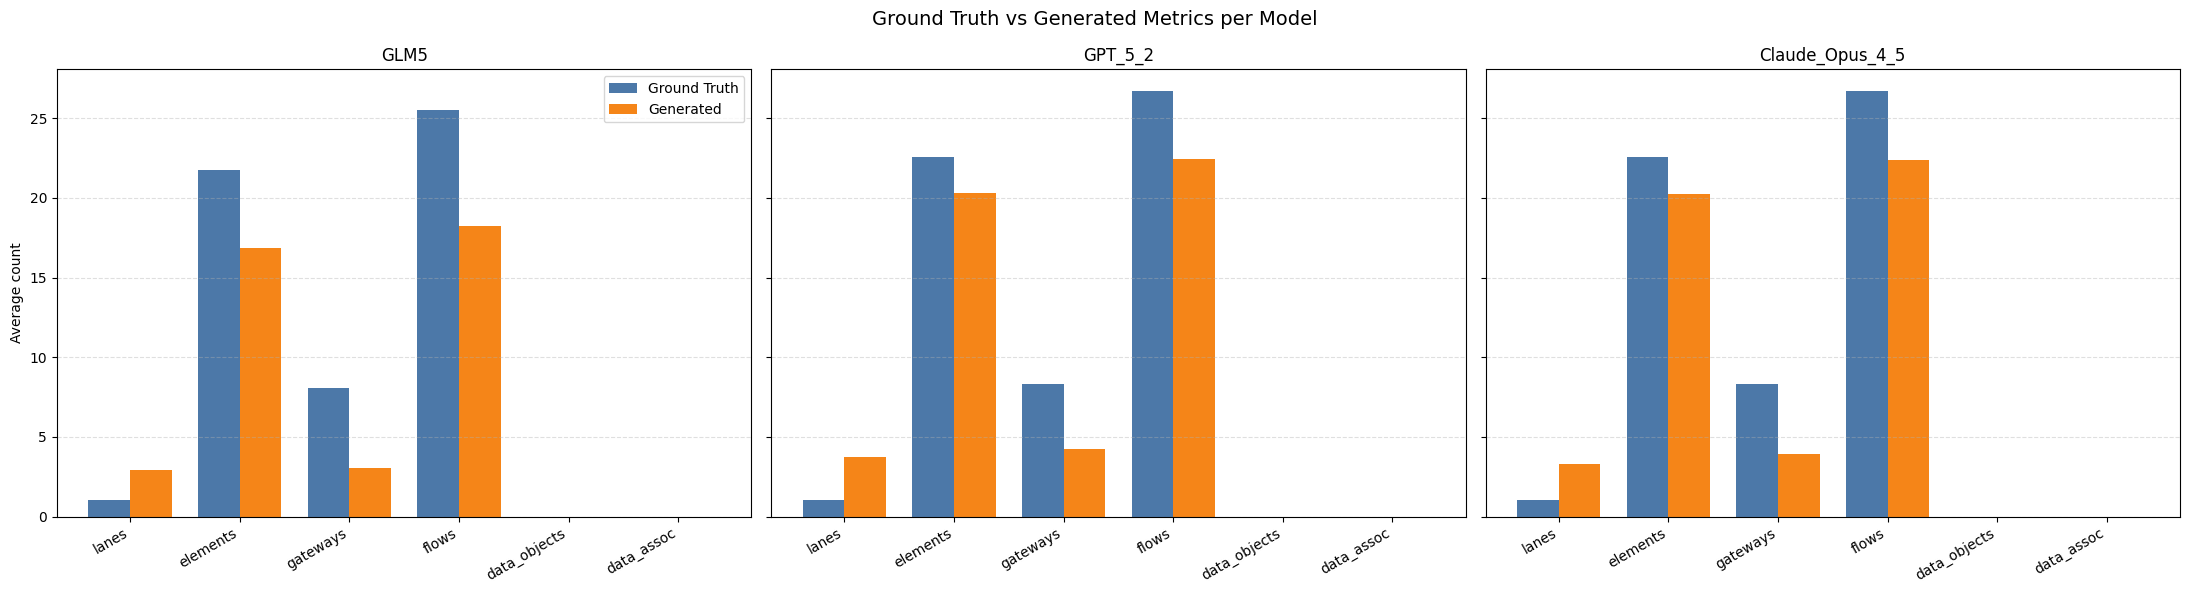

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics to compare
metrics_plot = ["lanes", "elements", "gateways", "flows", "data_objects", "data_assoc"]
models = ["GLM5", "GPT_5_2", "Claude_Opus_4_5"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

for ax, model in zip(axes, models):
    df_model = all_results[model]

    gt_means = [df_model[f"GT_{m}"].mean() for m in metrics_plot]
    gen_means = [df_model[f"GEN_{m}"].mean() for m in metrics_plot]

    x = np.arange(len(metrics_plot))
    width = 0.38

    ax.bar(x - width/2, gt_means, width, label="Ground Truth", color="#4C78A8")
    ax.bar(x + width/2, gen_means, width, label="Generated", color="#F58518")

    ax.set_title(model)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_plot, rotation=30, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Average count")
axes[0].legend(loc="upper right")
fig.suptitle("Ground Truth vs Generated Metrics per Model", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Build a dataframe with Ground Truth elements and generated elements for each model
gt_source = "Claude_Opus_4_5"

elements_df = all_results[gt_source][["Sample_Index", "GT_elements"]].rename(
    columns={"GT_elements": "GroundTruth_elements"}
)

for model in ["GLM5", "GPT_5_2", "Claude_Opus_4_5"]:
    model_df = all_results[model][["Sample_Index", "GEN_elements"]].rename(
        columns={"GEN_elements": f"{model}_elements"}
    )
    elements_df = elements_df.merge(model_df, on="Sample_Index", how="outer")

elements_df["GLM5_elements"] = elements_df["GLM5_elements"].fillna(0)

elements_df = elements_df.sort_values("Sample_Index").reset_index(drop=True)
elements_df

,Sample_Index,GroundTruth_elements,GLM5_elements,GPT_5_2_elements,Claude_Opus_4_5_elements
0,0,16,12.0,14,15
1,1,26,19.0,26,21
2,2,21,0.0,13,15
3,3,20,10.0,12,16
4,4,17,15.0,16,17
5,5,20,11.0,18,20
6,6,33,16.0,24,22
7,7,18,18.0,13,19
8,8,23,12.0,12,12
9,9,23,17.0,16,20


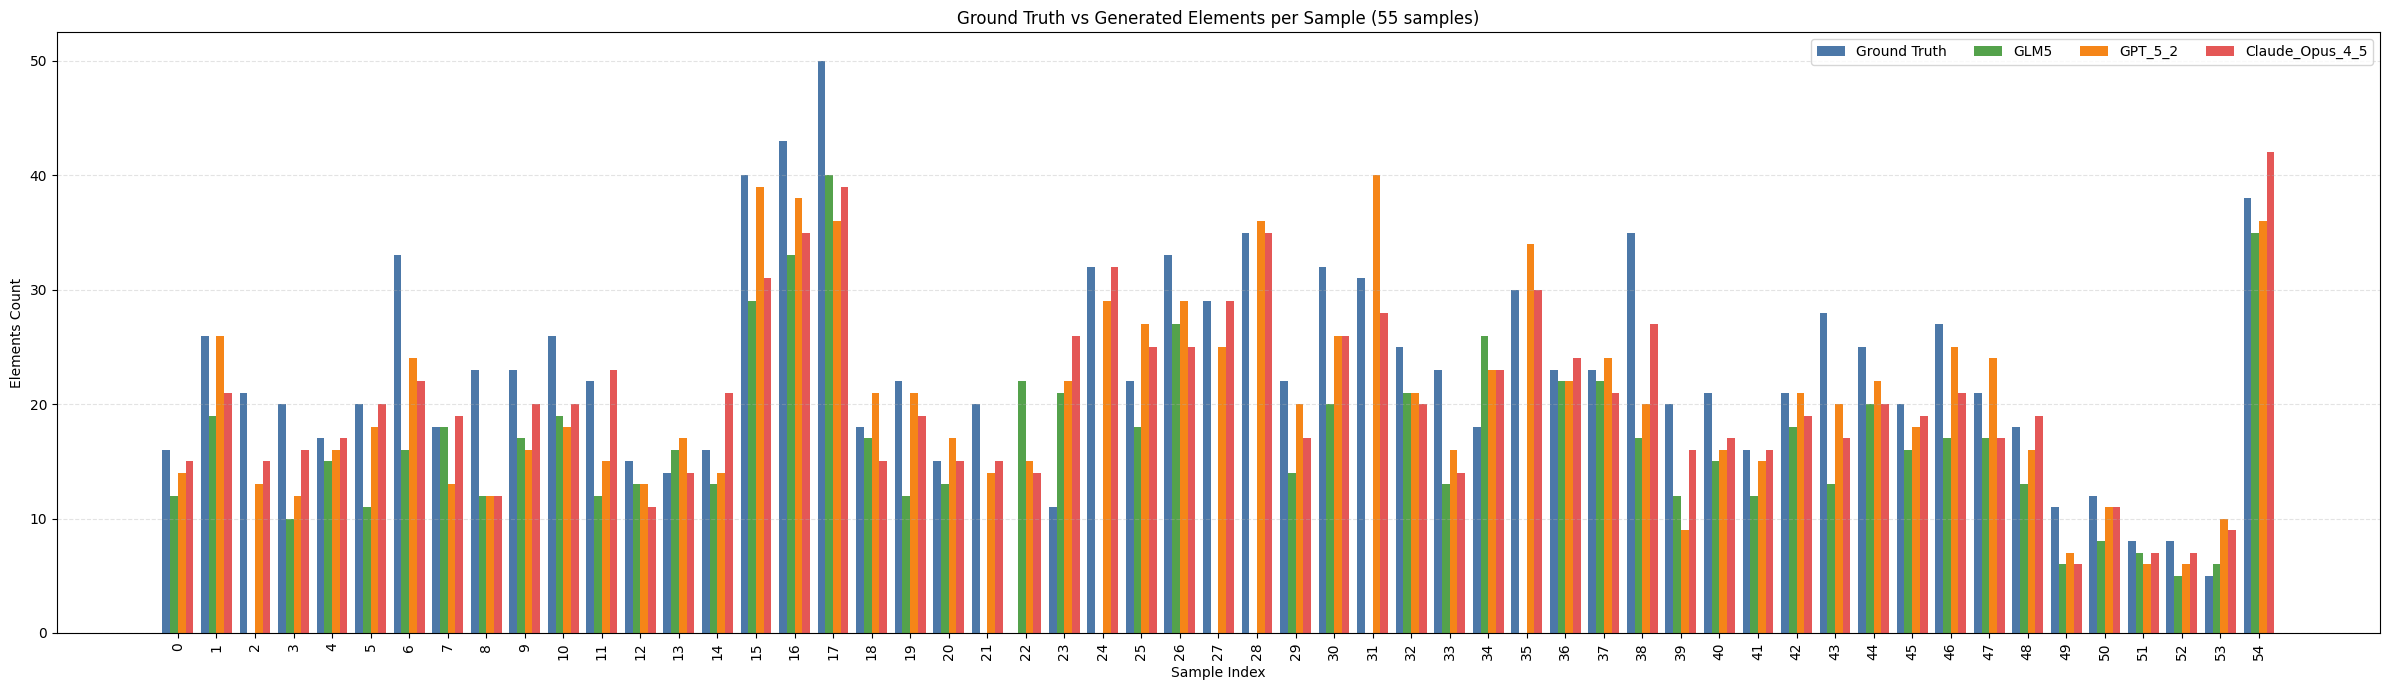

In [17]:
# Grouped bar chart: Ground Truth vs 3 models for each sample
plot_df = elements_df.copy().sort_values("Sample_Index").reset_index(drop=True)

# Keep first 55 samples (as requested)
plot_df = plot_df.iloc[:55].fillna(0)

x = np.arange(len(plot_df))
w = 0.2

plt.figure(figsize=(24, 7))
plt.bar(x - 1.5*w, plot_df["GroundTruth_elements"], width=w, label="Ground Truth", color="#4C78A8")
plt.bar(x - 0.5*w, plot_df["GLM5_elements"], width=w, label="GLM5", color="#54A24B")
plt.bar(x + 0.5*w, plot_df["GPT_5_2_elements"], width=w, label="GPT_5_2", color="#F58518")
plt.bar(x + 1.5*w, plot_df["Claude_Opus_4_5_elements"], width=w, label="Claude_Opus_4_5", color="#E45756")

plt.xticks(x, plot_df["Sample_Index"], rotation=90)
plt.xlabel("Sample Index")
plt.ylabel("Elements Count")
plt.title("Ground Truth vs Generated Elements per Sample (55 samples)")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(ncol=4, loc="upper right")
plt.tight_layout()
plt.show()

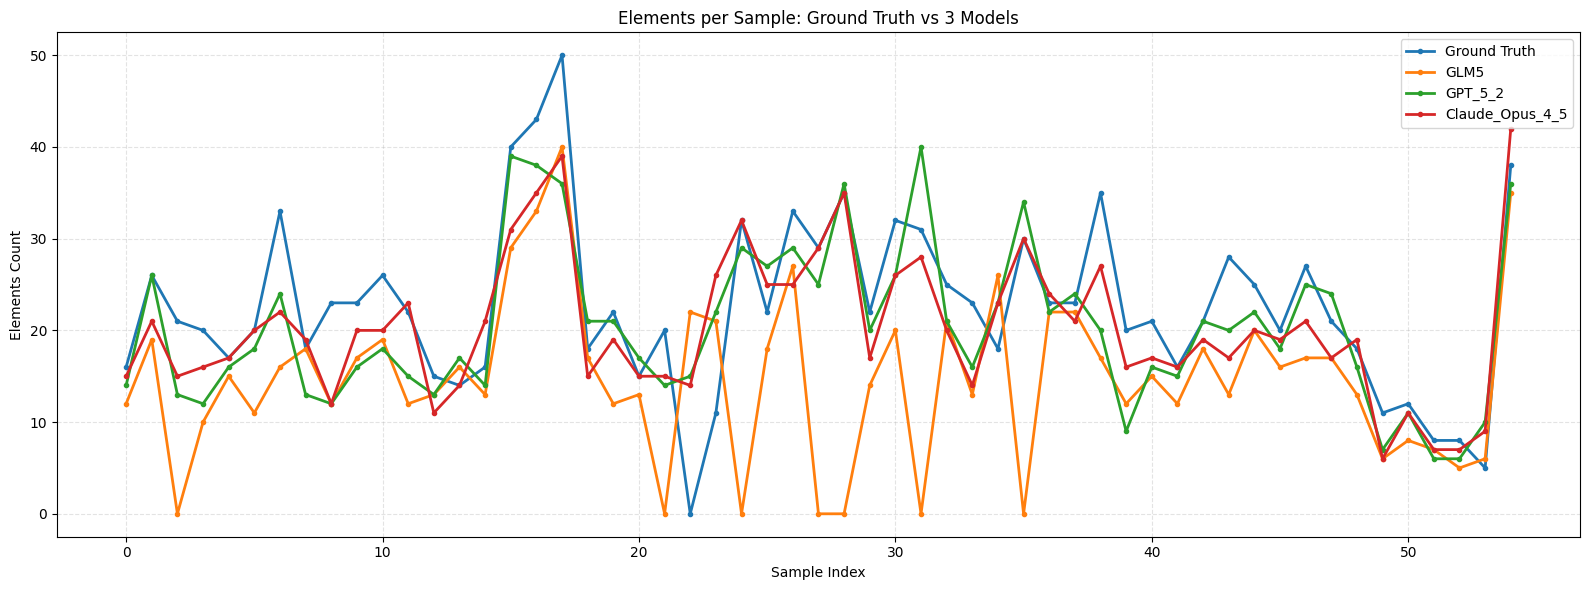

In [19]:
# 4-curve line plot: Ground Truth + 3 models
line_df = plot_df.copy().sort_values("Sample_Index")

plt.figure(figsize=(16, 6))
plt.plot(line_df["Sample_Index"], line_df["GroundTruth_elements"], label="Ground Truth", linewidth=2, marker="o", markersize=3)
plt.plot(line_df["Sample_Index"], line_df["GLM5_elements"], label="GLM5", linewidth=2, marker="o", markersize=3)
plt.plot(line_df["Sample_Index"], line_df["GPT_5_2_elements"], label="GPT_5_2", linewidth=2, marker="o", markersize=3)
plt.plot(line_df["Sample_Index"], line_df["Claude_Opus_4_5_elements"], label="Claude_Opus_4_5", linewidth=2, marker="o", markersize=3)

plt.xlabel("Sample Index")
plt.ylabel("Elements Count")
plt.title("Elements per Sample: Ground Truth vs 3 Models")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

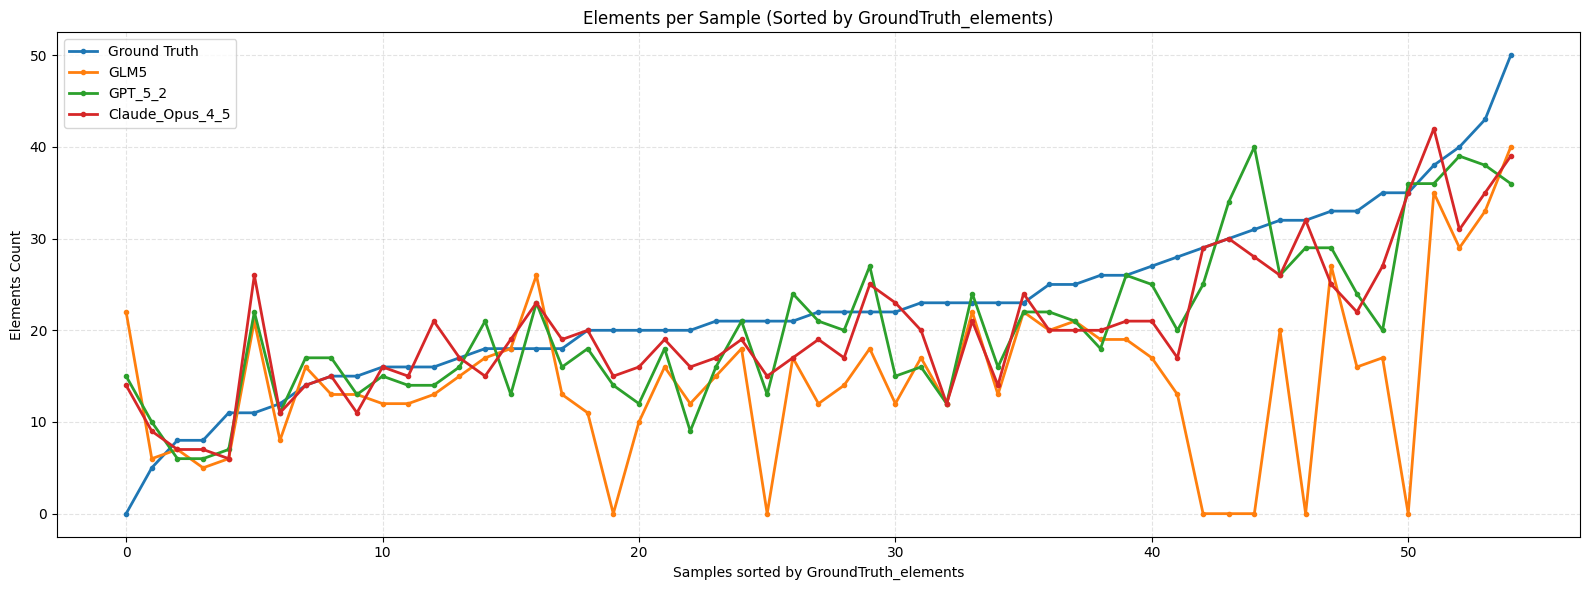

In [20]:
# Plot after sorting by Ground Truth elements
# sorted_df = plot_df.sort_values("GroundTruth_elements").reset_index(drop=True)
sorted_df = elements_df.copy().sort_values("GroundTruth_elements").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(sorted_df["GroundTruth_elements"].values, label="Ground Truth", linewidth=2, marker="o", markersize=3)
plt.plot(sorted_df["GLM5_elements"].values, label="GLM5", linewidth=2, marker="o", markersize=3)
plt.plot(sorted_df["GPT_5_2_elements"].values, label="GPT_5_2", linewidth=2, marker="o", markersize=3)
plt.plot(sorted_df["Claude_Opus_4_5_elements"].values, label="Claude_Opus_4_5", linewidth=2, marker="o", markersize=3)

plt.xlabel("Samples sorted by GroundTruth_elements")
plt.ylabel("Elements Count")
plt.title("Elements per Sample (Sorted by GroundTruth_elements)")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()